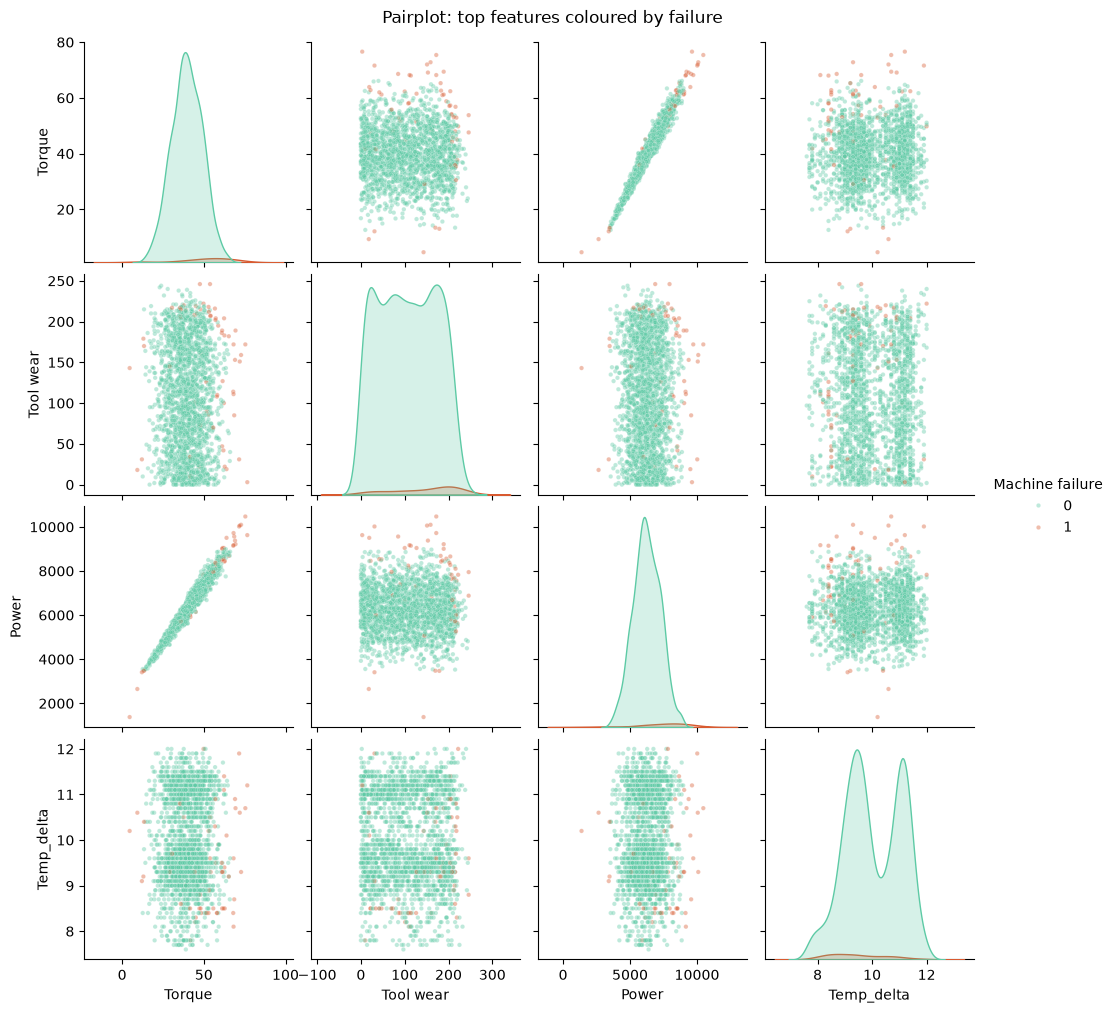

In [14]:
import seaborn as sns

top_features = ['Torque', 'Tool wear', 'Power', 'Temp_delta', 'Machine failure']

sample = df[top_features].sample(2000, random_state=42)

g = sns.pairplot(sample, hue='Machine failure', diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 10},
                 palette={0: '#5DCAA5', 1: '#D85A30'})
g.fig.suptitle('Pairplot: top features coloured by failure', y=1.01)
plt.savefig('../docs/pairplot.png', dpi=120)
plt.show()

In [12]:
df.to_csv('../data/processed/ai4i_engineered.csv', index=False)
print(f"Final engineered dataset: {df.shape}")
print(f"Feature columns: {df.shape[1] - 7}")  # subtract target + ID cols

Final engineered dataset: (10000, 50)
Feature columns: 43


In [11]:
# Power = Torque × Rotational speed (in radians/sec)
df['Power'] = df['Torque'] * (df['Rotational speed'] * 2 * np.pi / 60)
df['Temp_delta'] = df['Process temperature'] - df['Air temperature']

print("Power range:", df['Power'].min(), "–", df['Power'].max())
print("Temp delta range:", df['Temp_delta'].min(), "–", df['Temp_delta'].max())

Power range: 1148.4406104462848 – 10469.923004765631
Temp delta range: 7.599999999999966 – 12.100000000000023


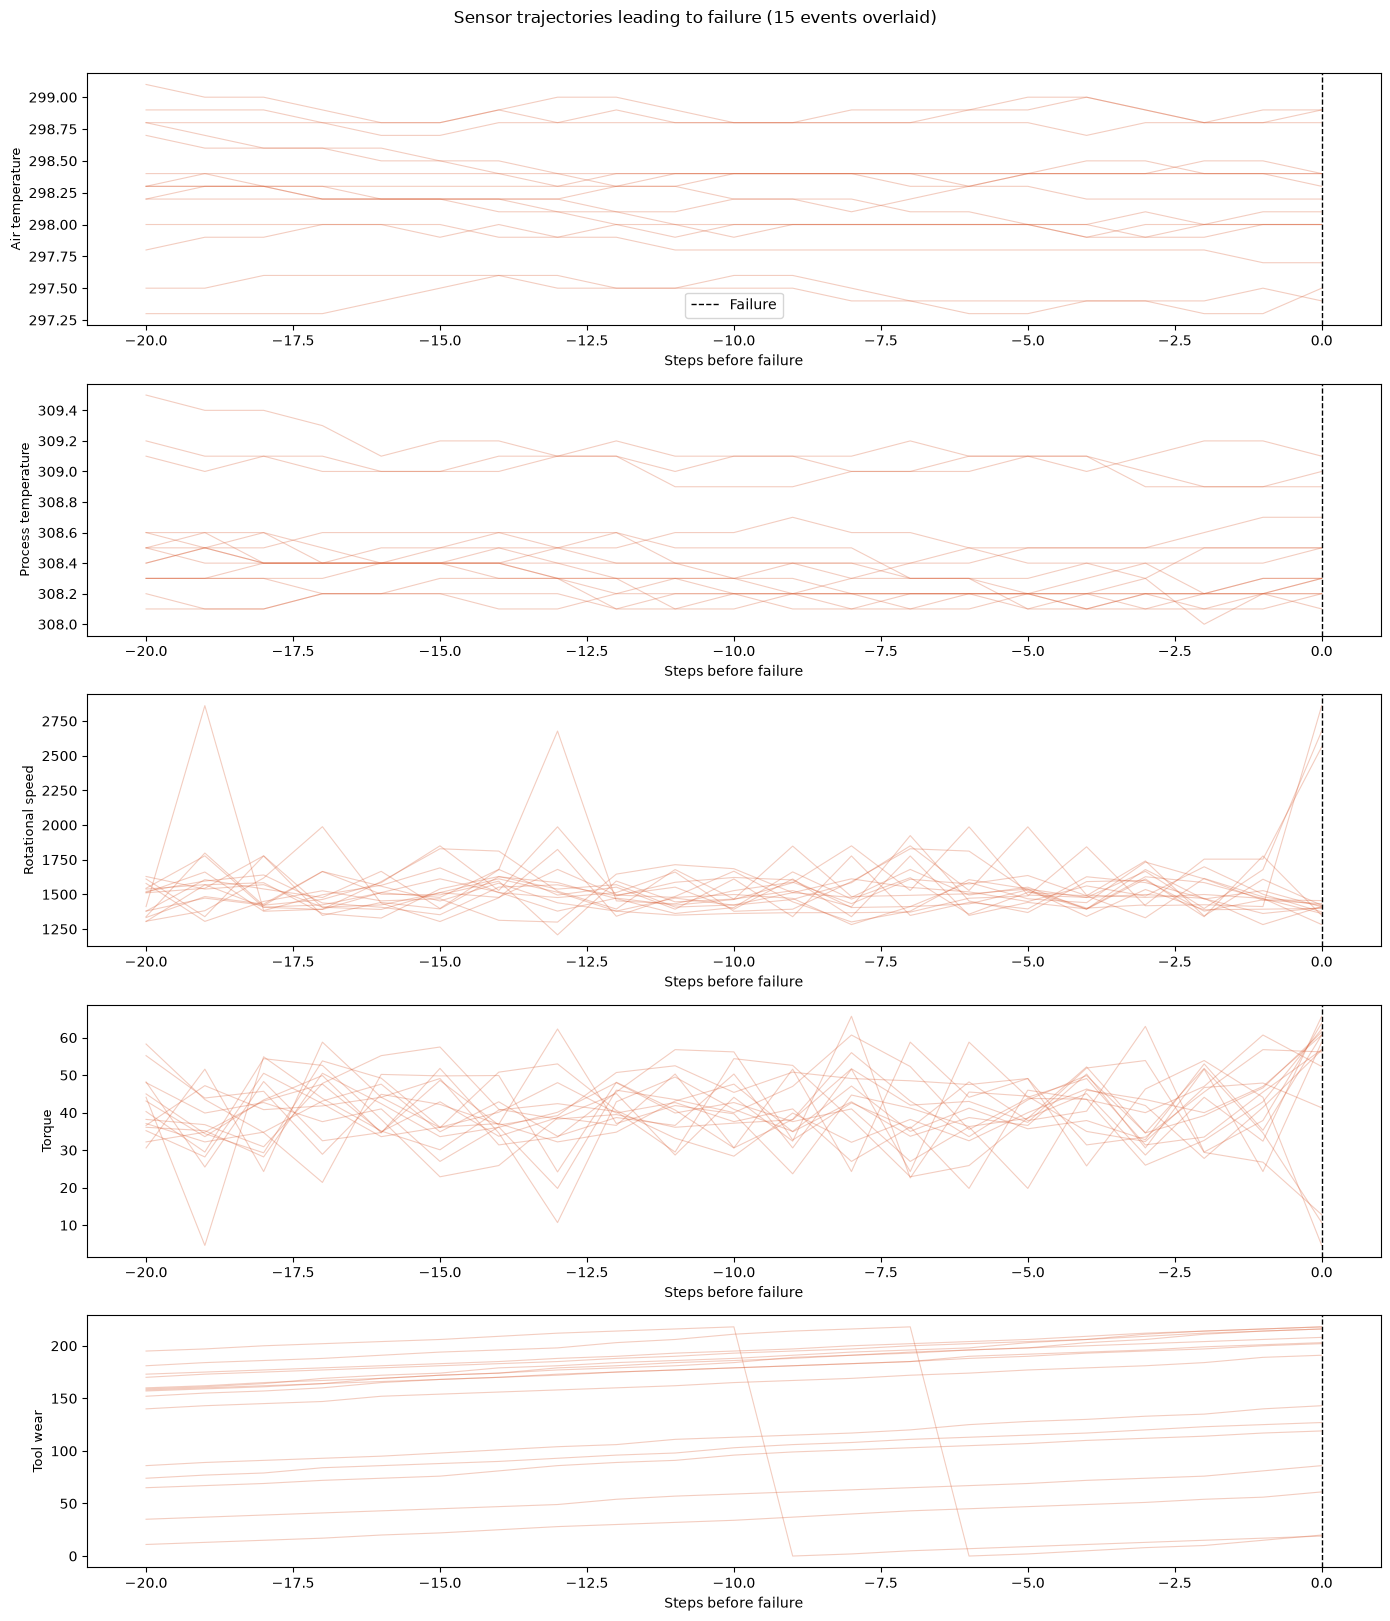

In [6]:
# Find all failure events and look at sensor values leading up to them
import matplotlib.pyplot as plt


failure_indices = df[df['Machine failure'] == 1].index.tolist()

lookback = 20  # look 20 steps before each failure

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(14, 16))

for i, col in enumerate(sensor_cols):
    for idx in failure_indices[:15]:  # plot first 15 failure events
        start = max(0, idx - lookback)
        window = df.loc[start:idx, col].values
        steps = np.arange(-len(window)+1, 1)
        axes[i].plot(steps, window, alpha=0.3, linewidth=0.8, color='#D85A30')

    axes[i].axvline(0, color='black', linestyle='--', linewidth=1, label='Failure')
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].set_xlabel('Steps before failure')

axes[0].legend()
plt.suptitle('Sensor trajectories leading to failure (15 events overlaid)', y=1.01)
plt.tight_layout()
plt.savefig('../docs/pre_failure_signals.png', dpi=150)
plt.show()

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/ai4i_clean.csv')

# Sort by UDI (sequential machine ID = proxy for time)
df = df.reset_index(drop=True)
df['UDI'] = df.index  # create it ourselves so the rest of the notebook works

sensor_cols = ['Air temperature', 'Process temperature',
               'Rotational speed', 'Torque', 'Tool wear']

for col in sensor_cols:
    short = col.replace(' ', '_')   # no brackets to strip anymore
    df[f'{short}_roll6_mean']  = df[col].rolling(6,  min_periods=1).mean()
    df[f'{short}_roll6_std']   = df[col].rolling(6,  min_periods=1).std().fillna(0)
    df[f'{short}_roll24_mean'] = df[col].rolling(24, min_periods=1).mean()
    df[f'{short}_roll24_std']  = df[col].rolling(24, min_periods=1).std().fillna(0)
    df[f'{short}_delta']       = df[col].diff().fillna(0)
    df[f'{short}_lag1']        = df[col].shift(1).bfill()
    df[f'{short}_lag6']        = df[col].shift(6).bfill()

print(f"Features after engineering: {df.shape[1]}")
df.head()

Features after engineering: 48


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,...,Torque_delta,Torque_lag1,Torque_lag6,Tool_wear_roll6_mean,Tool_wear_roll6_std,Tool_wear_roll24_mean,Tool_wear_roll24_std,Tool_wear_delta,Tool_wear_lag1,Tool_wear_lag6
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,...,0.0,42.8,42.8,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,...,3.5,42.8,42.8,1.500000,2.121320,1.500000,2.121320,3.0,0.0,0.0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,...,3.1,46.3,42.8,2.666667,2.516611,2.666667,2.516611,2.0,3.0,0.0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,...,-9.9,49.4,42.8,3.750000,2.986079,3.750000,2.986079,2.0,5.0,0.0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,...,0.5,39.5,42.8,4.800000,3.492850,4.800000,3.492850,2.0,7.0,0.0
